# IMEN266 · Ch.4 · Class Problems 3 — Modeling with a discrete-time Markov chain

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

For *modeling* problems the "analytic" object is the transition matrix $P$ itself,
and the simulation checks that a long sample path **reproduces $P$ empirically**
(and that the chain really forgets its past). *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class. A `check(...)` cell right after tells you immediately whether your matrix
matches the reference.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch04/notebooks/CP3_dtmc_modeling.ipynb`

*AI policy:* you may use an AI assistant on any TODO — but you must be able to
explain every line, and the `check` must pass. See `docs/ai_usage_guide.pdf`.

**The modeling recipe** *(slide p. 7/52)* — used in every problem below:
1. define $X_n$, the state at the $n$-th observation;
2. write down $\mathcal S$, the state space;
3. verify the Markov and time-homogeneity properties;
4. derive $P$, the transition probability matrix (rows sum to 1);
5. draw the transition diagram.

In [1]:
# --- IMEN266 setup (Ch.4): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.dtmc import DTMC
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.dtmc import DTMC
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def build_chain(P, states=None):
    """DTMC(P) if P is complete and valid; otherwise None (keeps 'Run all' alive)."""
    P = np.asarray(P, dtype=float)
    if np.isnan(P).any():
        print("[TODO] P still contains NaN entries - finish the TODO above."); return None
    try:
        return DTMC(P, states)
    except ValueError as e:
        print("[X  ] P is not a valid transition matrix:", e); return None

def check_rows(P):
    """Every row of a transition matrix must sum to 1 (and be nonnegative)."""
    P = np.asarray(P, dtype=float)
    err = None if np.isnan(P).any() else float(np.abs(P.sum(axis=1) - 1).max() + (P < 0).sum())
    return check("rows sum to 1, entries >= 0", err, 0.0, tol=1e-9)

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  DTMC imported.  Widgets available:", HAS_W)

Setup OK.  DTMC imported.  Widgets available: True


---
## Warm-up · What is a stochastic process? *(slide p. 1/52)*

A stochastic process is an **indexed family of random variables** $\{X_t,\,t\in\mathcal I\}$.
Both the index set and the state space can be discrete or continuous — the four
panels below are the four cells of the table on the slide. Ch.4 lives in the
top-left cell (discrete time, discrete state); Ch.5–7 move to continuous time.

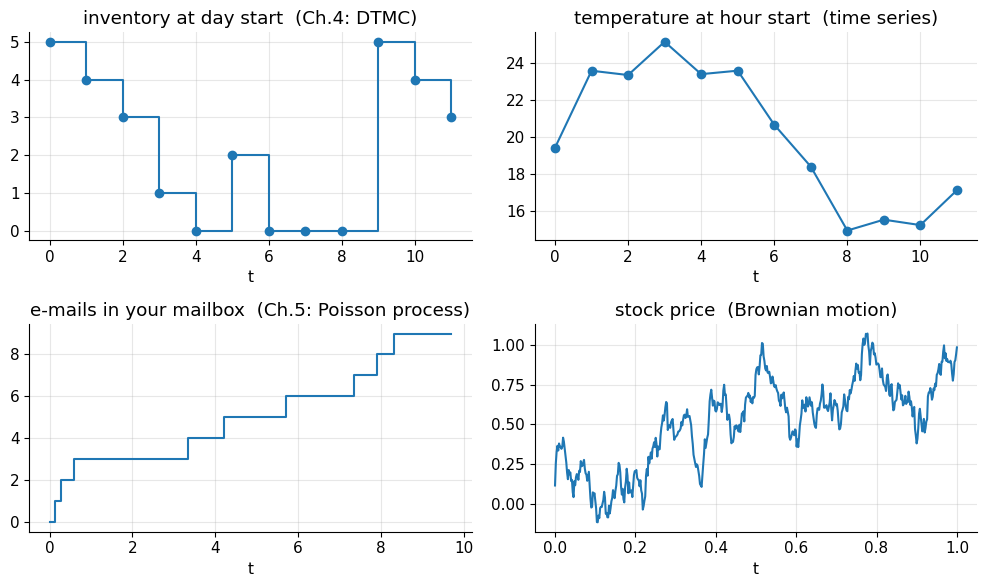

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# discrete index, discrete state: inventory at the beginning of each day
inv = np.maximum(5 - rng.poisson(1.0, 12).cumsum() % 6, 0)
ax[0, 0].step(range(12), inv, where="post", marker="o"); ax[0, 0].set_title("inventory at day start  (Ch.4: DTMC)")

# discrete index, continuous state: temperature at the beginning of each hour
temp = 20 + 5*np.sin(np.arange(12)/12*2*np.pi) + rng.normal(0, .8, 12)
ax[0, 1].plot(range(12), temp, "o-"); ax[0, 1].set_title("temperature at hour start  (time series)")

# continuous index, discrete state: e-mails received over time (counting process)
arrivals = np.cumsum(rng.exponential(1.0, 10)); t = np.linspace(0, arrivals[-1], 400)
ax[1, 0].step(t, np.searchsorted(arrivals, t), where="post"); ax[1, 0].set_title("e-mails in your mailbox  (Ch.5: Poisson process)")

# continuous index, continuous state: Brownian motion
ax[1, 1].plot(np.linspace(0, 1, 500), rng.normal(0, 1/np.sqrt(500), 500).cumsum()); ax[1, 1].set_title("stock price  (Brownian motion)")
for a in ax.flat: a.set_xlabel("t")
plt.tight_layout(); plt.show()

---
## Problem 1 — Machine up / down *(slide p. 3/52)*

> A company manufactures a machine that is either up or down. If it is up at the
> beginning of a day, then it is up at the beginning of the next day with
> probability 0.98 (regardless of the history of the machine); or it fails with
> probability 0.02. Once the machine goes down, the company sends a repair person
> to repair it. If the machine is down at the beginning of a day, it is down at
> the beginning of the next day with probability 0.03 (regardless of the history
> of the machine); or the repair completes and the machine is up with probability
> 0.97. A repaired machine is as good as new. Let $X_n$ be the state of the machine
> at the beginning of the $n$-th day. **Model $\{X_n, n\ge0\}$ as a DTMC.**

### Model
$X_n\in\mathcal S=\{0=\text{down},\,1=\text{up}\}$. "Regardless of the history"
*is* the Markov property, and the probabilities do not depend on $n$
(time-homogeneous). Rows = current state, columns = next state:
$$P=\begin{pmatrix}0.03&0.97\\0.02&0.98\end{pmatrix}.$$

DTMC(n=2, states=['down', 'up'])


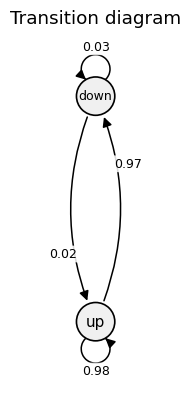

In [4]:
states = ["down", "up"]
P = np.array([[0.03, 0.97],      # from down: stays down / repaired
              [0.02, 0.98]])     # from up  : fails      / stays up

machine = build_chain(P, states)
print(machine)
machine.plot_transition_diagram(); plt.title("Transition diagram"); plt.show()

In [5]:
check_rows(P)
check("P(up -> down)",   P[1, 0], 0.02, tol=1e-9)
check("P(down -> down)", P[0, 0], 0.03, tol=1e-9)

[OK ] rows sum to 1, entries >= 0: got 0   (reference 0)
[OK ] P(up -> down): got 0.02   (reference 0.02)
[OK ] P(down -> down): got 0.03   (reference 0.03)


True

empirical P from the path:
 [[0.0358 0.9642]
 [0.0203 0.9797]]
P(up tomorrow | up today, up yesterday)   = 0.9797
P(up tomorrow | up today, down yesterday) = 0.9799   <- same: history is irrelevant


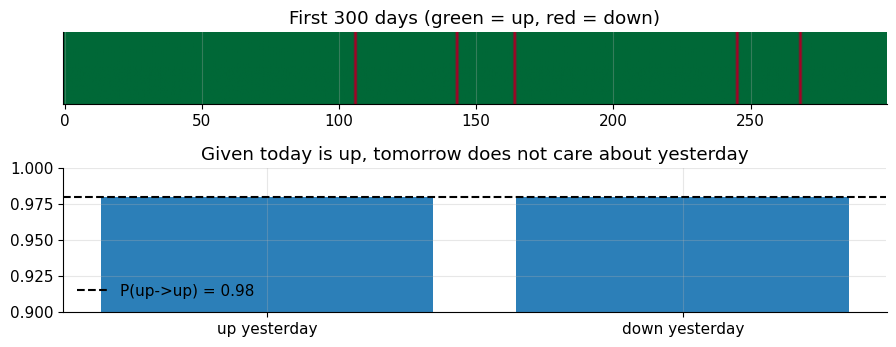

In [6]:
# --- Simulate 100,000 days and test the two things the model claims ------------
if machine is None:
    print("(finish the TODO first)")
else:
    x = machine.sample_path(100_000, x0="up", rng=rng)
    print("empirical P from the path:\n", machine.empirical_P(x).round(4))

    # Markov check: does yesterday matter once we know today?
    up_today = x[1:-1] == 1
    f_yest_up   = np.mean(x[2:][up_today & (x[:-2] == 1)] == 1)   # P(up tmrw | up today, up yest)
    f_yest_down = np.mean(x[2:][up_today & (x[:-2] == 0)] == 1)   # P(up tmrw | up today, down yest)
    print(f"P(up tomorrow | up today, up yesterday)   = {f_yest_up:.4f}")
    print(f"P(up tomorrow | up today, down yesterday) = {f_yest_down:.4f}   <- same: history is irrelevant")

    fig, ax = plt.subplots(2, 1, figsize=(9, 3.6), gridspec_kw={"height_ratios": [1, 2]})
    ax[0].imshow(x[:300][None, :], cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax[0].set_yticks([]); ax[0].set_title("First 300 days (green = up, red = down)")
    ax[1].bar(["up yesterday", "down yesterday"], [f_yest_up, f_yest_down], color="#2c7fb8")
    ax[1].axhline(0.98, ls="--", c="k", label="P(up->up) = 0.98"); ax[1].set_ylim(0.9, 1.0)
    ax[1].set_title("Given today is up, tomorrow does not care about yesterday"); ax[1].legend()
    plt.tight_layout(); plt.show()

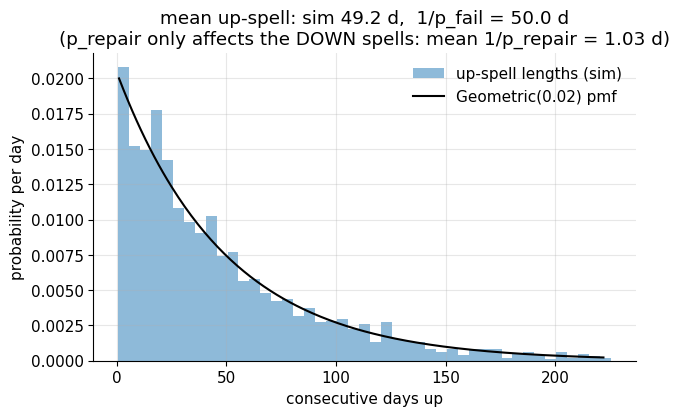

In [7]:
def machine_exp(p_fail=0.02, p_repair=0.97, days=100_000):
    """How long does the machine stay up between failures?  In a DTMC the time spent in a state is Geometric."""
    ch = DTMC([[1-p_repair, p_repair], [p_fail, 1-p_fail]], ["down", "up"])
    x = ch.sample_path(days, x0="up", rng=np.random.default_rng(1))
    edges = np.diff(np.r_[0, x, 0])                                   # +1 where an up-spell starts, -1 where it ends
    up_len = np.where(edges == -1)[0] - np.where(edges == 1)[0]       # lengths of the up-spells (days)
    kmax = int(np.quantile(up_len, .99)); ks = np.arange(1, kmax + 1); width = max(1, kmax // 40)
    plt.figure()
    plt.hist(up_len, bins=np.arange(0.5, kmax + width + 0.5, width), density=True, alpha=.5, label="up-spell lengths (sim)")
    plt.plot(ks, (1 - p_fail) ** (ks - 1) * p_fail, "k-", label=f"Geometric({p_fail}) pmf")
    plt.xlabel("consecutive days up"); plt.ylabel("probability per day"); plt.legend()
    plt.title(f"mean up-spell: sim {up_len.mean():.1f} d,  1/p_fail = {1/p_fail:.1f} d\n(p_repair only affects the DOWN spells: mean 1/p_repair = {1/p_repair:.2f} d)")
    plt.show()

show(machine_exp,
     p_fail=FloatSlider(min=.005, max=.2, step=.005, value=.02) if HAS_W else .02,
     p_repair=FloatSlider(min=.5, max=.99, step=.01, value=.97) if HAS_W else .97)

**Think about it** — (i) Which phrase in the problem statement licenses the
Markov property, and which one licenses time-homogeneity? (ii) The experiment
shows that the number of consecutive up-days is Geometric$(0.02)$, mean 50 days.
Which property of a DTMC forces *every* stay in a state to be geometric? (Keep
this in mind for Problem 6, where a tool's lifetime is **not** geometric.)
*(Companion §1.2, Proof 1.)*

---
## Problem 2 — Weather in Pohang *(slide p. 8/52)*

> The weather in the city of Pohang is classified as sunny, cloudy or rainy.
> Suppose that tomorrow's weather depends only on today's weather as follows: If
> it is sunny today, it is cloudy tomorrow with probability 0.3 and rainy with
> probability 0.2; if it is cloudy today, it is sunny tomorrow with probability
> 0.5 and rainy with probability 0.3; and finally, if it is rainy today, it is
> sunny tomorrow with probability 0.4 and cloudy with probability 0.5. Let $X_n$ be
> the type of the $n$-th day. **Model $\{X_n, n\ge0\}$ as a DTMC.**

### Model
$X_n=0$ if day $n$ is sunny, $1$ if cloudy, $2$ if rainy; $\mathcal S=\{0,1,2\}$
(a random variable takes **numbers** as values; the letters are only our
reading of them). Each row gives two probabilities explicitly; the third is
*forced* by "rows sum to 1".

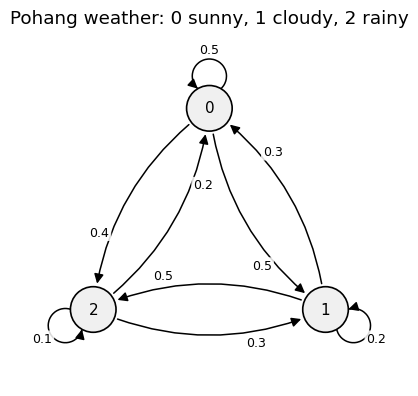

In [8]:
W = [0, 1, 2]                          # X_n = 0 sunny, 1 cloudy, 2 rainy (as on the slides)
P_w = np.array([[0.5, 0.3, 0.2],      # sunny today
                [0.5, 0.2, 0.3],      # cloudy today
                [0.4, 0.5, 0.1]])     # rainy today
weather = build_chain(P_w, W)
weather.plot_transition_diagram(); plt.title("Pohang weather: 0 sunny, 1 cloudy, 2 rainy"); plt.show()

In [9]:
check_rows(P_w)
check("P(0 -> 0) sunny stays sunny", P_w[0, 0], 0.5, tol=1e-9)
check("P(2 -> 2) rainy stays rainy", P_w[2, 2], 0.1, tol=1e-9)

[OK ] rows sum to 1, entries >= 0: got 0   (reference 0)
[OK ] P(0 -> 0) sunny stays sunny: got 0.5   (reference 0.5)
[OK ] P(2 -> 2) rainy stays rainy: got 0.1   (reference 0.1)


True

empirical P (50,000 days):
 [[0.504 0.299 0.197]
 [0.498 0.198 0.304]
 [0.401 0.5   0.099]]


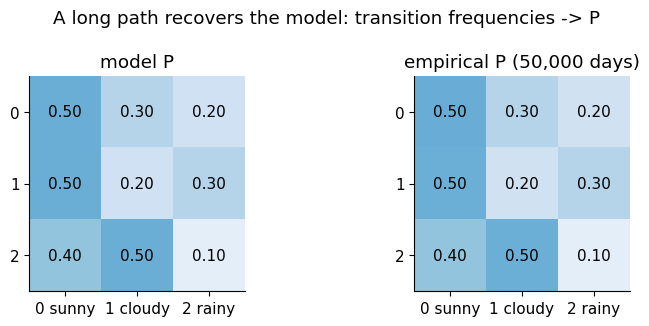

In [10]:
# --- Simulate: the empirical transition matrix converges to P -------------------
if weather is None:
    print("(finish the TODO first)")
else:
    x = weather.sample_path(50_000, x0=0, rng=rng)
    P_hat = weather.empirical_P(x)
    print("empirical P (50,000 days):\n", P_hat.round(3))

    fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
    for a, M, t in zip(ax, [P_w, P_hat], ["model P", "empirical P (50,000 days)"]):
        im = a.imshow(M, cmap="Blues", vmin=0, vmax=1)
        a.set_xticks(range(3), ["0 sunny", "1 cloudy", "2 rainy"]); a.set_yticks(range(3), ["0", "1", "2"]); a.set_title(t); a.grid(False)
        for i in range(3):
            for j in range(3): a.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center")
    plt.suptitle("A long path recovers the model: transition frequencies -> P"); plt.tight_layout(); plt.show()

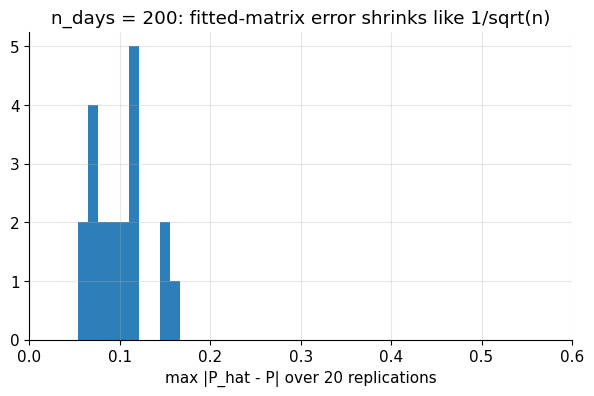

In [11]:
def fit_weather(n_days=200):
    """How many days of data do we need before the fitted P is trustworthy?"""
    P_ref = np.array([[0.5, 0.3, 0.2], [0.5, 0.2, 0.3], [0.4, 0.5, 0.1]])   # the model (independent of your TODO)
    ch = DTMC(P_ref, W)
    errs = []
    for seed in range(20):
        x = ch.sample_path(n_days, x0=0, rng=np.random.default_rng(seed))
        errs.append(np.nanmax(np.abs(ch.empirical_P(x) - P_ref)))
    plt.figure(); plt.hist(errs, bins=10, color="#2c7fb8")
    plt.xlabel("max |P_hat - P| over 20 replications"); plt.xlim(0, 0.6)
    plt.title(f"n_days = {n_days}: fitted-matrix error shrinks like 1/sqrt(n)"); plt.show()

show(fit_weather, n_days=IntSlider(min=20, max=5000, step=20, value=200) if HAS_W else 200)

**Think about it** — (i) The statement says "tomorrow's weather depends only on
today's". Rewrite that sentence as the conditional-probability identity that
defines a Markov chain. (ii) *HW 2 Part C* asks what happens when you fit this
model to weather that actually has memory (long sunny spells). What would you
expect the fitted $P$ to get right, and what would it get wrong?

---
## Problem 3 — Himart inventory *(slide p. 10/52)*

> Himart stocks a wide variety of PCs for retail sales. It is open for business
> Monday through Friday 8am to 5pm. It uses the following operating policy to
> control the inventory of Paint-yum PCs: At 5pm Friday, the store clerk checks
> to see how many Paint-yum PCs are still in stock. If the number is less than 2,
> then he orders enough Paint-yum PCs to bring the stock up to 5 at the beginning
> of the business day Monday. If the number in stock is 2 or more, no action is
> taken. The demand for Paint-yum PCs during the week is a Poisson random
> variable with mean 3. Any demand that cannot be immediately satisfied is lost.
> **Develop a DTMC to model the inventory of Paint-yum PCs at Himart.**
>
> | $k$ | 0 | 1 | 2 | 3 | 4 |
> |---|---|---|---|---|---|
> | $P[\text{Demand}=k]$ | 0.0498 | 0.1494 | 0.2240 | 0.2240 | 0.1680 |
> | $P[\text{Demand}\ge k]$ | 1.0000 | 0.9502 | 0.8008 | 0.5768 | 0.3528 |

### Model
$X_n$ = stock on **Monday morning** of week $n$ (after any order). Because an
order brings the level to 5 and no order is placed at 2 or more,
$\mathcal S=\{2,3,4,5\}$. With weekly demand $D\sim\text{Poisson}(3)$ and lost
sales, Friday stock is $(i-D)^+$; if it is $\le1$ (i.e. $D\ge i-1$) Monday
starts at 5, otherwise at $i-D$:
$$P_{i,\,i-d}=P(D=d)\ \ (0\le d\le i-2),\qquad
P_{i,5}=P(D\ge i-1)\;[+P(D=0)\text{ if }i=5].$$
Note the **tail probability** in the last column — that is what lost sales does.

In [12]:
S_inv = [2, 3, 4, 5]
pmf  = stats.poisson.pmf(np.arange(0, 6), 3)      # P(D = d), d = 0..5
tail = stats.poisson.sf(np.arange(0, 6) - 1, 3)   # P(D >= d)

def himart_P(s=2, S=5, lam=3.0):
    """Order-up-to policy: Friday stock < s  ->  Monday stock = S."""
    states = list(range(s, S + 1))
    P = np.zeros((len(states), len(states)))
    for a, i in enumerate(states):
        for d in range(0, i - s + 1):                      # no order: i - d >= s
            P[a, states.index(i - d)] += stats.poisson.pmf(d, lam)
        P[a, states.index(S)] += stats.poisson.sf(i - s, lam)   # order: D >= i - s + 1
    return states, P

S_inv, P_inv = himart_P()
print("P (rows/cols = Monday stock 2,3,4,5):\n", P_inv.round(4))
himart = build_chain(P_inv, S_inv)

P (rows/cols = Monday stock 2,3,4,5):
 [[0.0498 0.     0.     0.9502]
 [0.1494 0.0498 0.     0.8009]
 [0.224  0.1494 0.0498 0.5768]
 [0.224  0.224  0.1494 0.4026]]


In [13]:
check_rows(P_inv)
check("P(5 -> 5)", P_inv[3, 3], stats.poisson.pmf(0, 3) + stats.poisson.sf(3, 3), tol=1e-6)   # 0.4026
check("P(4 -> 2)", P_inv[2, 0], stats.poisson.pmf(2, 3), tol=1e-6)                             # 0.2240
check("P(3 -> 5)", P_inv[1, 3], stats.poisson.sf(1, 3), tol=1e-6)                              # 0.8008

[OK ] rows sum to 1, entries >= 0: got 0   (reference 0)
[OK ] P(5 -> 5): got 0.402555   (reference 0.402555)
[OK ] P(4 -> 2): got 0.224042   (reference 0.224042)
[OK ] P(3 -> 5): got 0.800852   (reference 0.800852)


np.True_

empirical P from the simulated store:
 [[0.044 0.    0.    0.956]
 [0.146 0.055 0.    0.799]
 [0.223 0.154 0.041 0.582]
 [0.22  0.229 0.152 0.399]]
model P:
 [[0.05  0.    0.    0.95 ]
 [0.149 0.05  0.    0.801]
 [0.224 0.149 0.05  0.577]
 [0.224 0.224 0.149 0.403]]


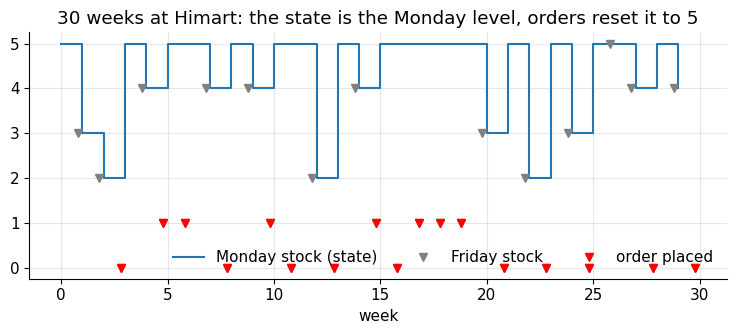

In [14]:
# --- Simulate the store week by week (policy, not the matrix!) and compare -------
if himart is None:
    print("(finish the TODO first)")
else:
    weeks = 20_000
    monday = np.empty(weeks + 1, int); friday = np.empty(weeks, int); order = np.zeros(weeks, bool)
    monday[0] = 5
    D = rng.poisson(3, weeks)
    for n in range(weeks):
        friday[n] = max(monday[n] - D[n], 0)                  # lost sales: never negative
        order[n] = friday[n] < 2
        monday[n + 1] = 5 if order[n] else friday[n]
    idx = np.searchsorted(S_inv, monday)                      # state indices
    print("empirical P from the simulated store:\n", himart.empirical_P(idx).round(3))
    print("model P:\n", P_inv.round(3))

    plt.figure(figsize=(9, 3.2))
    n = np.arange(30)
    plt.step(n, monday[:30], where="post", label="Monday stock (state)")
    plt.plot(n + 0.8, friday[:30], "v", c="gray", label="Friday stock")
    plt.plot(n[order[:30]] + 0.8, friday[:30][order[:30]], "rv", label="order placed")
    plt.yticks(range(6)); plt.xlabel("week"); plt.legend(loc="lower right", ncol=3)
    plt.title("30 weeks at Himart: the state is the Monday level, orders reset it to 5"); plt.show()

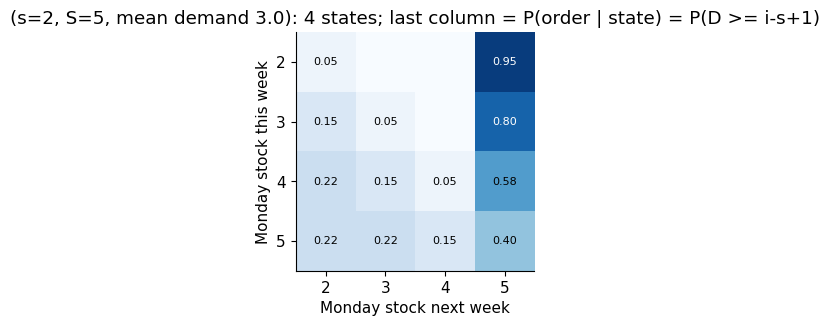

In [15]:
def order_up_to_P(s=2, S=5, lam=3.0):
    """Transition matrix of the (s, S) order-up-to policy (independent of your TODO above)."""
    states = list(range(s, S + 1))
    P = np.zeros((len(states), len(states)))
    for a, i in enumerate(states):
        for d in range(0, i - s + 1):                          # no order: i - d >= s
            P[a, states.index(i - d)] += stats.poisson.pmf(d, lam)
        P[a, states.index(S)] += stats.poisson.sf(i - s, lam)   # order: D >= i - s + 1
    return states, P

def inventory_exp(s=2, S=5, lam=3.0):
    """How the policy parameters shape P: the state space is {s, ..., S}; the last column is P(order | Monday stock)."""
    states, P = order_up_to_P(s, S, lam)
    fig, ax = plt.subplots(figsize=(1.2 + 0.7 * len(states), 0.9 + 0.55 * len(states)))
    ax.imshow(P, cmap="Blues", vmin=0, vmax=1); ax.grid(False)
    ax.set_xticks(range(len(states)), states); ax.set_yticks(range(len(states)), states)
    ax.set_xlabel("Monday stock next week"); ax.set_ylabel("Monday stock this week")
    for i in range(len(states)):
        for j in range(len(states)):
            if P[i, j] > 0.005: ax.text(j, i, f"{P[i, j]:.2f}", ha="center", va="center", fontsize=8, color="w" if P[i, j] > .6 else "k")
    ax.set_title(f"(s={s}, S={S}, mean demand {lam}): {len(states)} states; last column = P(order | state) = P(D >= i-s+1)")
    plt.show()

show(inventory_exp,
     s=IntSlider(min=1, max=4, value=2) if HAS_W else 2,
     S=IntSlider(min=5, max=12, value=5) if HAS_W else 5,
     lam=FloatSlider(min=.5, max=8, step=.5, value=3) if HAS_W else 3.0)

**Think about it** — (i) Why is the state defined on *Monday morning* and not
Friday evening? Would Friday stock also be a DTMC — with which state space?
(ii) The last column uses $P(D\ge\cdot)$ while the others use $P(D=\cdot)$.
Point to the sentence in the problem that causes this asymmetry.
*(HW 2 Part B dissects an AI solution that gets exactly this wrong.)*

---
## Problem 4 — Two routes *(slide p. 12/52)*

> There are two identical routes for messages to traverse from node A to node B.
> If a route was congested when a message needed to be sent, then it will be
> congested with probability $q$ when the next message needs to be sent.
> Likewise, if a route was congestion-free when a message needed to be sent, then
> it will be congestion-free with probability $p$ when the next message needs to
> be sent. The two routes behave independently. Let $X_n$ be the number of routes
> available when the $n$-th message is attempted. **Show that $\{X_n,n\ge0\}$ is a
> DTMC.**

### Model
Each route is a 2-state chain (congested $\to$ congested w.p. $q$, free $\to$ free
w.p. $p$). $X_n\in\{0,1,2\}$ counts free routes. Because the routes are
**identical and independent**, the next count depends only on the current count:
$$X_{n+1}\mid X_n{=}0\sim\text{Bin}(2,1{-}q),\quad
X_{n+1}\mid X_n{=}2\sim\text{Bin}(2,p),\quad
X_{n+1}\mid X_n{=}1\sim\text{Bern}(p)+\text{Bern}(1{-}q).$$

In [16]:
def routes_P(p, q):
    return np.array([[q**2,          2*q*(1-q),                 (1-q)**2],
                     [(1-p)*q,       p*q + (1-p)*(1-q),         p*(1-q)],
                     [(1-p)**2,      2*p*(1-p),                 p**2]])

p, q = 0.8, 0.6
P_r = routes_P(p, q)
routes = build_chain(P_r, [0, 1, 2])
print(P_r.round(4))

[[0.36 0.48 0.16]
 [0.12 0.56 0.32]
 [0.04 0.32 0.64]]


In [17]:
check_rows(P_r)
check("P(1 -> 1) at p=.8, q=.6", P_r[1, 1], 0.8*0.6 + 0.2*0.4, tol=1e-9)   # 0.56
check("P(1 -> 2)",              P_r[1, 2], 0.8*0.4, tol=1e-9)             # 0.32

[OK ] rows sum to 1, entries >= 0: got 0   (reference 0)
[OK ] P(1 -> 1) at p=.8, q=.6: got 0.56   (reference 0.56)
[OK ] P(1 -> 2): got 0.32   (reference 0.32)


True

empirical P of the COUNT process:
 [[0.358 0.478 0.164]
 [0.121 0.557 0.322]
 [0.042 0.319 0.639]]
model P:
 [[0.36 0.48 0.16]
 [0.12 0.56 0.32]
 [0.04 0.32 0.64]]


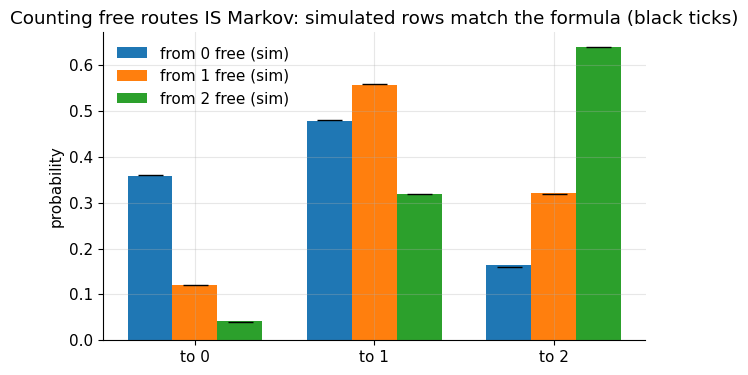

In [18]:
# --- Simulate the TWO routes separately, then count -----------------------------
if routes is None:
    print("(finish the TODO first)")
else:
    route = DTMC([[q, 1-q], [1-p, p]], ["congested", "free"])
    n = 100_000
    r1 = route.sample_path(n, rng=rng); r2 = route.sample_path(n, rng=rng)
    X = r1 + r2                                            # number of free routes
    P_hat = routes.empirical_P(X)
    print("empirical P of the COUNT process:\n", P_hat.round(3))
    print("model P:\n", P_r.round(3))

    plt.figure()
    w = .25; xs = np.arange(3)
    for k in range(3):
        plt.bar(xs + (k-1)*w, P_hat[k], w, label=f"from {k} free (sim)")
        plt.plot(xs + (k-1)*w, P_r[k], "k_", ms=18)
    plt.xticks(xs, ["to 0", "to 1", "to 2"]); plt.ylabel("probability")
    plt.title("Counting free routes IS Markov: simulated rows match the formula (black ticks)")
    plt.legend(); plt.show()

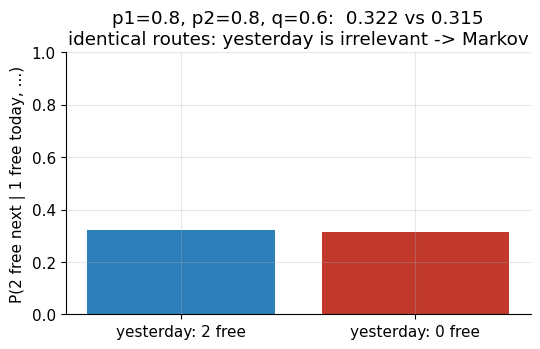

In [19]:
def routes_P_ref(p, q):
    """Reference transition matrix (independent of your TODO): each route flips independently."""
    return np.array([[q**2,      2*q*(1-q),           (1-q)**2],
                     [(1-p)*q,   p*q + (1-p)*(1-q),   p*(1-q)],
                     [(1-p)**2,  2*p*(1-p),           p**2]])

def routes_exp(p1=0.8, p2=0.8, q=0.6):
    """Break the symmetry: route 1 stays free w.p. p1, route 2 w.p. p2.  Is the COUNT still Markov?
    Markov check: P(X_{n+1} = 2 | X_n = 1, X_{n-1} = 2)  vs  P(X_{n+1} = 2 | X_n = 1, X_{n-1} = 0)."""
    rng_ = np.random.default_rng(7); n = 200_000
    r1 = DTMC([[q, 1-q], [1-p1, p1]]).sample_path(n, rng=rng_)
    r2 = DTMC([[q, 1-q], [1-p2, p2]]).sample_path(n, rng=rng_)
    X = r1 + r2
    mid = X[1:-1] == 1
    f_from2 = np.mean(X[2:][mid & (X[:-2] == 2)] == 2)
    f_from0 = np.mean(X[2:][mid & (X[:-2] == 0)] == 2)
    plt.figure(figsize=(6, 3.4))
    plt.bar(["yesterday: 2 free", "yesterday: 0 free"], [f_from2, f_from0], color=["#2c7fb8", "#c0392b"])
    plt.ylabel("P(2 free next | 1 free today, ...)"); plt.ylim(0, 1)
    same = "identical routes: yesterday is irrelevant -> Markov" if abs(p1 - p2) < 1e-9 else "different routes: yesterday matters -> the count is NOT Markov"
    plt.title(f"p1={p1}, p2={p2}, q={q}:  {f_from2:.3f} vs {f_from0:.3f}\n{same}"); plt.show()

show(routes_exp,
     p1=FloatSlider(min=.05, max=.99, step=.01, value=.8) if HAS_W else .8,
     p2=FloatSlider(min=.05, max=.99, step=.01, value=.8) if HAS_W else .8,
     q=FloatSlider(min=.05, max=.99, step=.01, value=.6) if HAS_W else .6)

**Think about it** — (i) $X_n$ is a *function* of the 4-state chain
(route 1, route 2). Functions of Markov chains are usually **not** Markov. Before
moving the sliders, predict: with $p_1\ne p_2$, why does knowing that *yesterday*
both routes were free change your forecast for tomorrow, given that *today* one
route is free? (Which route is more likely to be the free one?) (ii) Write the
$4\times4$ matrix of the pair (route 1, route 2) as a product of the two $2\times2$
matrices (independence), and show how the $3\times3$ matrix of the count is
obtained from it by adding columns and (only because of the symmetry) rows.

---
## Problem 5 — The lady with $r$ umbrellas *(slide p. 14/52)*

> An individual possesses $r$ umbrellas, which she employs in going from her home
> to office and vice versa. If she is at home (the office) at the beginning (end)
> of a day and it is raining, then she will take an umbrella with her to the
> office (home), provided there is one to be taken. If it is not raining, then
> she never takes an umbrella. Assume that, independent of the past, it rains at
> the beginning (end) of a day with probability $p$. **Define a DTMC with $r+1$
> states that will help us determine the proportion of time that our individual
> gets wet.** Note: She gets wet if it is raining and all the umbrellas are at her
> other location.

### Model
$X_n$ = number of umbrellas at her **current** location at the start of trip $n$,
$\mathcal S=\{0,1,\dots,r\}$. If $X_n=0$ all $r$ umbrellas are at the other end,
so $X_{n+1}=r$. If $X_n=i\ge1$: rain (prob $p$) $\Rightarrow$ she carries one
$\Rightarrow$ $X_{n+1}=r-i+1$; no rain $\Rightarrow$ $X_{n+1}=r-i$.
She gets wet on a trip iff $X_n=0$ **and** it rains.

[[0.  0.  0.  1. ]
 [0.  0.  0.6 0.4]
 [0.  0.6 0.4 0. ]
 [0.6 0.4 0.  0. ]]


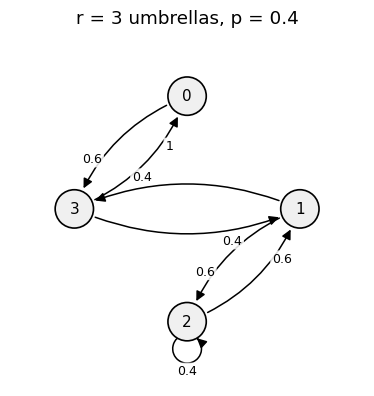

In [20]:
def umbrella_P(r, p):
    P = np.zeros((r + 1, r + 1))
    P[0, r] = 1.0
    for i in range(1, r + 1):
        P[i, r - i]     += 1 - p        # no rain: umbrellas stay put
        P[i, r - i + 1] += p            # rain: one umbrella travels with her
    return P

r, p = 3, 0.4
P_u = umbrella_P(r, p)
umbrella = build_chain(P_u, list(range(r + 1)))
print(P_u)
umbrella.plot_transition_diagram(); plt.title(f"r = {r} umbrellas, p = {p}"); plt.show()

In [21]:
check_rows(P_u)
check("P(1 -> 3)  (r=3, p=.4: rain, carries the last umbrella)", P_u[1, 3], 0.4, tol=1e-9)
check("P(3 -> 0)  (no rain, all stay behind)",                   P_u[3, 0], 0.6, tol=1e-9)

[OK ] rows sum to 1, entries >= 0: got 0   (reference 0)
[OK ] P(1 -> 3)  (r=3, p=.4: rain, carries the last umbrella): got 0.4   (reference 0.4)
[OK ] P(3 -> 0)  (no rain, all stay behind): got 0.6   (reference 0.6)


True

empirical P from the simulated trips:
 [[0.    0.    0.    1.   ]
 [0.    0.    0.6   0.4  ]
 [0.    0.6   0.4   0.   ]
 [0.596 0.404 0.    0.   ]]
model P:
 [[0.  0.  0.  1. ]
 [0.  0.  0.6 0.4]
 [0.  0.6 0.4 0. ]
 [0.6 0.4 0.  0. ]]
(CP5 #3 uses this chain to compute the proportion of trips on which she gets wet)


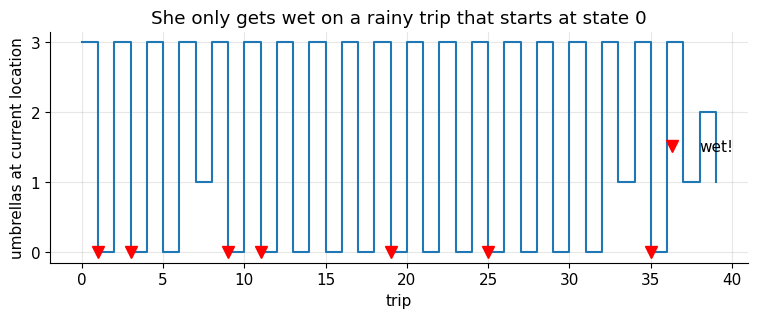

In [22]:
# --- Simulate trips: count how often she gets wet -------------------------------
if umbrella is None:
    print("(finish the TODO first)")
else:
    trips = 200_000
    rain = rng.random(trips) < p
    here = np.empty(trips + 1, int); here[0] = r
    for n in range(trips):
        i = here[n]
        take = rain[n] and i > 0
        here[n + 1] = r - i + (1 if take else 0)
    wet = rain & (here[:-1] == 0)                          # the event the state was designed to capture
    print("empirical P from the simulated trips:\n", umbrella.empirical_P(here).round(3))
    print("model P:\n", P_u.round(3))
    print("(CP5 #3 uses this chain to compute the proportion of trips on which she gets wet)")

    plt.figure(figsize=(9, 3))
    plt.step(range(40), here[:40], where="post"); plt.plot(np.where(wet[:40])[0], np.zeros(wet[:40].sum()), "rv", ms=9, label="wet!")
    plt.yticks(range(r + 1)); plt.xlabel("trip"); plt.ylabel("umbrellas at current location")
    plt.title("She only gets wet on a rainy trip that starts at state 0"); plt.legend(); plt.show()

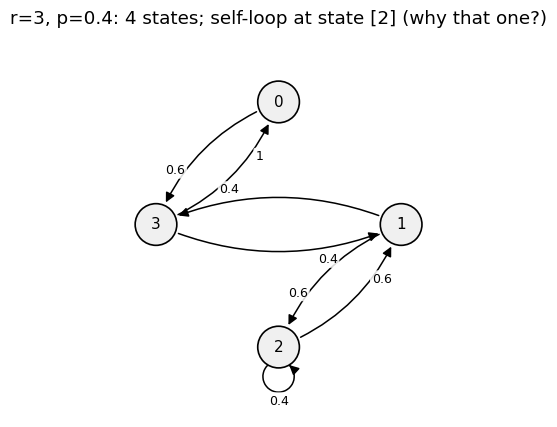

In [23]:
def umbrella_P_ref(r, p):
    """Reference matrix (independent of your TODO)."""
    P = np.zeros((r + 1, r + 1)); P[0, r] = 1.0
    for i in range(1, r + 1):
        P[i, r - i] += 1 - p; P[i, r - i + 1] += p
    return P

def umbrella_exp(r=3, p=0.4):
    """The structure of P as r and p change: from i she goes to r-i (dry) or r-i+1 (rain); state 0 is the 'wet risk' state."""
    ch = DTMC(umbrella_P_ref(r, p), list(range(r + 1)))
    fig, ax = plt.subplots(figsize=(6, 5)); ch.plot_transition_diagram(ax=ax)
    loops = [i for i in range(r + 1) if ch.P[i, i] > 0]
    ax.set_title(f"r={r}, p={p}: {r+1} states; self-loop at state {loops} (why that one?)"); plt.show()

show(umbrella_exp,
     r=IntSlider(min=1, max=8, value=3) if HAS_W else 3,
     p=FloatSlider(min=.05, max=.95, step=.05, value=.4) if HAS_W else .4)

**Think about it** — (i) "She gets wet" is the intersection of two events:
which two, and why are they independent? Write $P(\text{wet on trip }n)$ in terms
of $P(X_n=0)$ and $p$ — CP5 #3 computes it. (ii) Only one state has a self-loop,
and which one it is depends on whether $r$ is even or odd. Explain from the
transition rule, without looking at the diagram.

---
## Problem 6 — Age of a machine tool *(slide p. 16/52)*

> Consider a machine tool that is used on an NC-machine. The time to produce a
> part and inspect it is 1-hour. If the tool has produced $i$ parts, it fails with
> probability $p_i$. Let $X_n$ be the age of a machine tool at the beginning of
> the $n$-th hour. Assuming that a failed tool is replaced by a new tool whenever
> it fails, **model $\{X_n,n\ge0\}$ as a DTMC.**

### Model
$X_n\in\{0,1,2,\dots\}$ (age = parts produced). From age $i$: the tool fails during
the hour w.p. $p_i$ and is replaced $\Rightarrow$ age 0 next hour; otherwise age
$i+1$. In general the state space is infinite; if $p_K=1$ for some $K$ (a tool
never survives $K$ parts) it is $\{0,\dots,K\}$. We use
$p=(0.05,0.10,0.20,0.40,0.70,1.00)$ below — a wear-out profile.

In [24]:
p_fail = np.array([0.05, 0.10, 0.20, 0.40, 0.70, 1.00])     # p_0 .. p_5  (p_5 = 1: forced replacement)
K = len(p_fail) - 1

def tool_P(p_fail):
    K = len(p_fail) - 1
    P = np.zeros((K + 1, K + 1))
    for i in range(K + 1):
        P[i, 0] = p_fail[i]                     # fails -> new tool (age 0)
        if i < K:
            P[i, i + 1] = 1 - p_fail[i]         # survives -> one part older
    return P

P_t = tool_P(p_fail)
tool = build_chain(P_t, list(range(K + 1)))
print(P_t)

[[0.05 0.95 0.   0.   0.   0.  ]
 [0.1  0.   0.9  0.   0.   0.  ]
 [0.2  0.   0.   0.8  0.   0.  ]
 [0.4  0.   0.   0.   0.6  0.  ]
 [0.7  0.   0.   0.   0.   0.3 ]
 [1.   0.   0.   0.   0.   0.  ]]


In [25]:
check_rows(P_t)
check("P(2 -> 0)", P_t[2, 0], 0.20, tol=1e-9)
check("P(2 -> 3)", P_t[2, 3], 0.80, tol=1e-9)
check("P(5 -> 0)", P_t[5, 0], 1.00, tol=1e-9)

[OK ] rows sum to 1, entries >= 0: got 0   (reference 0)
[OK ] P(2 -> 0): got 0.2   (reference 0.2)
[OK ] P(2 -> 3): got 0.8   (reference 0.8)
[OK ] P(5 -> 0): got 1   (reference 1)


True

mean lifetime (sim) = 4.030   tail-sum formula sum_k P(L>k) = 4.023


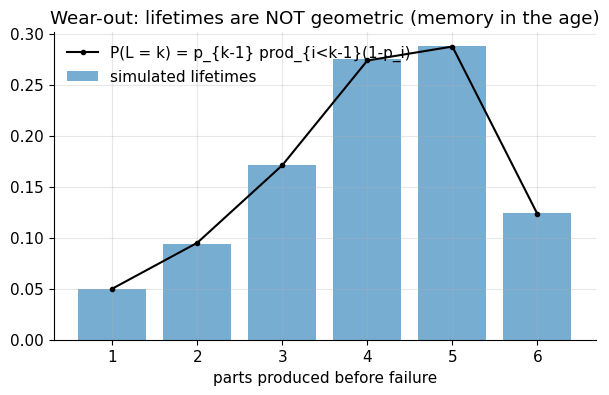

In [26]:
# --- Simulate: tool lifetimes = times between visits to age 0 --------------------
if tool is None:
    print("(finish the TODO first)")
else:
    x = tool.sample_path(200_000, x0=0, rng=rng)
    zeros = np.where(x == 0)[0]
    life = np.diff(zeros)                          # parts produced by each tool
    surv = np.cumprod(np.r_[1.0, 1 - p_fail[:-1]])  # P(lifetime > k) = prod_{i<k}(1-p_i)
    print(f"mean lifetime (sim) = {life.mean():.3f}   tail-sum formula sum_k P(L>k) = {surv.sum():.3f}")

    plt.figure()
    ks = np.arange(1, K + 2)
    plt.bar(ks, [np.mean(life == k) for k in ks], alpha=.6, label="simulated lifetimes")
    plt.plot(ks, surv * p_fail, "k.-", label="P(L = k) = p_{k-1} prod_{i<k-1}(1-p_i)")
    plt.xlabel("parts produced before failure"); plt.legend()
    plt.title("Wear-out: lifetimes are NOT geometric (memory in the age)"); plt.show()

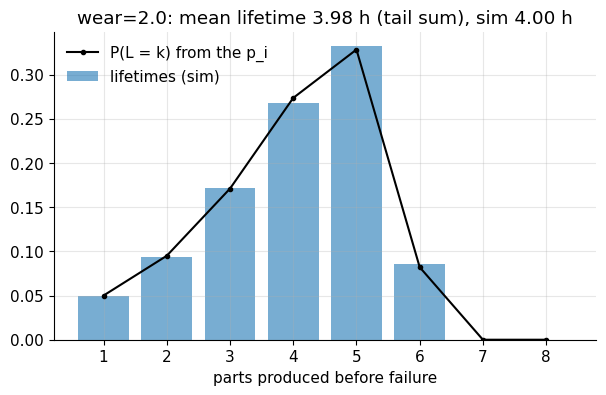

In [27]:
def tool_exp(wear=2.0):
    """p_i = min(1, 0.05 * wear**i): steeper wear-out with larger `wear`."""
    pf = np.minimum(1.0, 0.05 * wear ** np.arange(0, 8)); pf[-1] = 1.0
    P = np.zeros((len(pf), len(pf)))                       # reference matrix (independent of your TODO)
    for i in range(len(pf)):
        P[i, 0] = pf[i]
        if i < len(pf) - 1: P[i, i + 1] = 1 - pf[i]
    ch = DTMC(P, list(range(len(pf))))
    x = ch.sample_path(100_000, x0=0, rng=np.random.default_rng(2))
    life = np.diff(np.where(x == 0)[0])                        # lifetimes = gaps between visits to age 0
    surv = np.cumprod(np.r_[1.0, 1 - pf[:-1]])                 # P(L > k) = prod_{i<k} (1 - p_i)
    ks = np.arange(1, len(pf) + 1)
    plt.figure()
    plt.bar(ks, [np.mean(life == k) for k in ks], alpha=.6, label="lifetimes (sim)")
    plt.plot(ks, surv * pf, "k.-", label="P(L = k) from the p_i")
    plt.xlabel("parts produced before failure"); plt.legend()
    plt.title(f"wear={wear}: mean lifetime {surv.sum():.2f} h (tail sum), sim {life.mean():.2f} h"); plt.show()

show(tool_exp, wear=FloatSlider(min=1.0, max=3.0, step=.1, value=2.0) if HAS_W else 2.0)

**Think about it** — (i) If $p_i\equiv p$ for all $i$, the age process is
still Markov but the lifetime is Geometric$(p)$ — memoryless, exactly like the
up-spells of Problem 1. What in the transition matrix encodes "memory" when the
$p_i$ differ? (ii) The mean lifetime $\sum_k P(L>k)$ is the tail-sum formula from
Ch.1–3 (Companion Proof 3). Which state of this chain has a self-loop, and what
physical event does that loop represent?

---
## Problem 7 — Weather spells *(slide p. 18/52)*

> Consider the following weather forecasting model: if today is sunny (rainy) and
> it is the $k$-th day of the current sunny (rainy) spell, then it will be sunny
> (rainy) tomorrow with probability $p_k$ ($q_k$) regardless of what happened
> before the current sunny (rainy) spell started. **Model this as a DTMC.**

### Model
"Sunny/rainy" alone is **not** Markov here (the persistence depends on how long
the spell has lasted). Enlarge the state: $X_n=(\text{type},k)$ = today's type and
the day-count of the current spell. Then
$(S,k)\to(S,k{+}1)$ w.p. $p_k$, $(S,k)\to(R,1)$ w.p. $1-p_k$, and symmetrically
$(R,k)\to(R,k{+}1)$ w.p. $q_k$, $(R,k)\to(S,1)$ w.p. $1-q_k$. To keep the chain
finite we cap the count at $K$ (persistence constant beyond $K$).

In [28]:
def spell_P(p_k, q_k):
    """States: (S,1..K) then (R,1..K); p_k/q_k = persistence on day k (capped at K)."""
    K = len(p_k)
    states = [f"S{k}" for k in range(1, K + 1)] + [f"R{k}" for k in range(1, K + 1)]
    P = np.zeros((2 * K, 2 * K))
    for k in range(K):                       # index k <-> day k+1 of the spell
        nxt = min(k + 1, K - 1)              # cap the counter at K
        P[k, nxt]         += p_k[k]          # sunny persists
        P[k, K]           += 1 - p_k[k]      # spell breaks -> (R,1)
        P[K + k, K + nxt] += q_k[k]          # rainy persists
        P[K + k, 0]       += 1 - q_k[k]      # spell breaks -> (S,1)
    return states, P

p_k = np.array([0.6, 0.7, 0.8, 0.9])          # sunny spells strengthen with age
q_k = np.array([0.5, 0.4, 0.3, 0.2])          # rainy spells weaken with age
S_sp, P_sp = spell_P(p_k, q_k)
spells = build_chain(P_sp, S_sp)
print(S_sp); print(P_sp.round(2))

['S1', 'S2', 'S3', 'S4', 'R1', 'R2', 'R3', 'R4']
[[0.  0.6 0.  0.  0.4 0.  0.  0. ]
 [0.  0.  0.7 0.  0.3 0.  0.  0. ]
 [0.  0.  0.  0.8 0.2 0.  0.  0. ]
 [0.  0.  0.  0.9 0.1 0.  0.  0. ]
 [0.5 0.  0.  0.  0.  0.5 0.  0. ]
 [0.6 0.  0.  0.  0.  0.  0.4 0. ]
 [0.7 0.  0.  0.  0.  0.  0.  0.3]
 [0.8 0.  0.  0.  0.  0.  0.  0.2]]


In [29]:
check_rows(P_sp)
check("P((R,2) -> (R,3))", P_sp[5, 6], 0.4, tol=1e-9)
check("P((R,2) -> (S,1))", P_sp[5, 0], 0.6, tol=1e-9)

[OK ] rows sum to 1, entries >= 0: got 0   (reference 0)
[OK ] P((R,2) -> (R,3)): got 0.4   (reference 0.4)
[OK ] P((R,2) -> (S,1)): got 0.6   (reference 0.6)


True

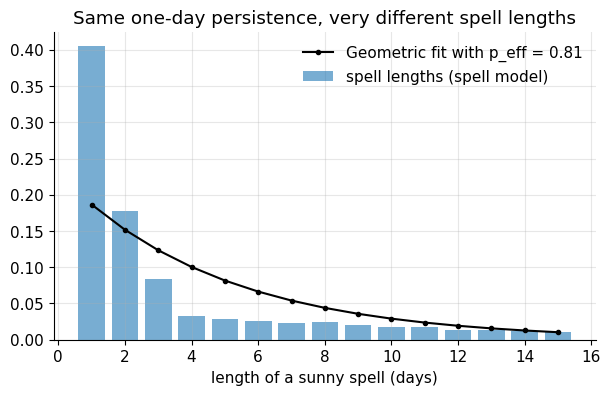

mean sunny spell: model 5.36 d, geometric fit 5.36 d  <- means agree by construction
P(spell >= 8 days): model 0.222   geometric fit 0.236  <- tails do not
std of spell length: model 7.74   geometric fit 4.83


In [30]:
# --- Simulate: sunny-spell lengths vs the memoryless (first-order) alternative ----
if spells is None:
    print("(finish the TODO first)")
else:
    x = spells.sample_path(200_000, x0="S1", rng=rng)
    sunny = x < len(p_k)
    # lengths of maximal runs of sunny days
    edges = np.diff(np.r_[0, sunny.astype(int), 0])
    lengths = np.where(edges == -1)[0] - np.where(edges == 1)[0]
    p_eff = np.mean(sunny[1:][sunny[:-1]])                     # P(sunny tmrw | sunny today), ignoring k
    ks = np.arange(1, 16)
    plt.figure()
    plt.bar(ks, [np.mean(lengths == k) for k in ks], alpha=.6, label="spell lengths (spell model)")
    plt.plot(ks, (1 - p_eff) * p_eff ** (ks - 1), "k.-", label=f"Geometric fit with p_eff = {p_eff:.2f}")
    plt.xlabel("length of a sunny spell (days)"); plt.legend()
    plt.title("Same one-day persistence, very different spell lengths"); plt.show()
    geo_tail = p_eff ** 7                                      # P(Geom >= 8)
    print(f"mean sunny spell: model {lengths.mean():.2f} d, geometric fit {1/(1-p_eff):.2f} d  <- means agree by construction")
    print(f"P(spell >= 8 days): model {np.mean(lengths >= 8):.3f}   geometric fit {geo_tail:.3f}  <- tails do not")
    print(f"std of spell length: model {lengths.std():.2f}   geometric fit {np.sqrt(p_eff)/(1-p_eff):.2f}")

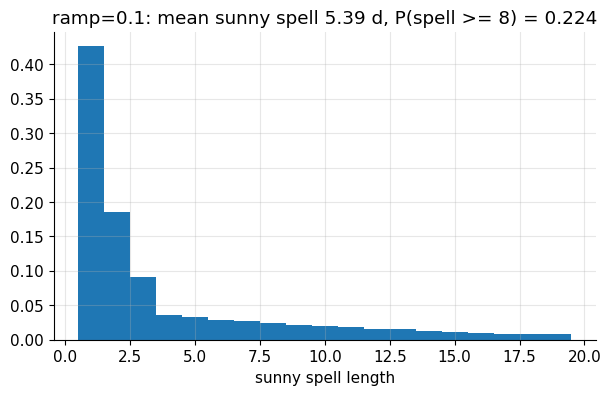

In [31]:
def spell_exp(ramp=0.1):
    """p_k rises from 0.6 by `ramp` per day of the spell (capped at 0.95)."""
    pk = np.minimum(0.95, 0.6 + ramp * np.arange(4)); qk = np.array([0.5, 0.4, 0.3, 0.2])
    K = len(pk); st = [f"S{k}" for k in range(1, K + 1)] + [f"R{k}" for k in range(1, K + 1)]
    P = np.zeros((2 * K, 2 * K))                            # reference matrix (independent of your TODO)
    for k in range(K):
        nxt = min(k + 1, K - 1)
        P[k, nxt] += pk[k];         P[k, K] += 1 - pk[k]
        P[K + k, K + nxt] += qk[k]; P[K + k, 0] += 1 - qk[k]
    ch = DTMC(P, st)
    x = ch.sample_path(100_000, x0="S1", rng=np.random.default_rng(5))
    sunny = x < 4; edges = np.diff(np.r_[0, sunny.astype(int), 0])
    L = np.where(edges == -1)[0] - np.where(edges == 1)[0]
    plt.figure(); plt.hist(L, bins=np.arange(0.5, 20.5), density=True)
    plt.xlabel("sunny spell length"); plt.title(f"ramp={ramp}: mean sunny spell {L.mean():.2f} d, P(spell >= 8) = {np.mean(L >= 8):.3f}"); plt.show()

show(spell_exp, ramp=FloatSlider(min=0, max=.12, step=.01, value=.1) if HAS_W else .1)

**Think about it** — (i) This is the standard trick for "non-Markov" data:
*put the memory into the state*. What is the price (count the states as $K$
grows)? (ii) **Bridge to HW 2 Part C:** if you only recorded sunny/rainy and
fitted a 2-state chain by transition frequencies, its $P(\text{sunny tomorrow}\mid\text{sunny today})$
would be the $p_{\text{eff}}$ of the simulation, so the *mean* spell length would
come out right — but the spell-length *distribution* would be geometric
(memoryless). Explain why the mean is safe and the distribution is not.

---
## Wrap-up

| # | system | state $X_n$ | $|\mathcal S|$ | modeling lesson |
|---|---|---|---|---|
| 1 | machine | up/down | 2 | "regardless of history" = Markov |
| 2 | Pohang weather | 0/1/2 (sunny/cloudy/rainy) | 3 | diagonal forced by row sums |
| 3 | Himart | Monday stock | 4 | tail probability from lost sales |
| 4 | two routes | # free routes | 3 | symmetry makes the count Markov |
| 5 | umbrellas | # at current location | $r{+}1$ | choose the state that answers the question |
| 6 | tool age | age | $K{+}1$ (or $\infty$) | age is the memory |
| 7 | weather spells | (type, day of spell) | $2K$ | enlarge the state to restore Markov |

**Next steps** → CP4 (transient analysis: $p_n=aP^n$) → Companion Ch.4
(Proofs 1–2 first) → CP5 (limits, costs).